# Lesson 2 - Preparing images for classification

> This material is intended exclusively for educational purposes. The models and results must not be used for clinical diagnosis.

## Dataset

The [Alzheimer's MRI Dataset](https://www.kaggle.com/datasets/ucimachinelearning/alzheimers-mri-dataset) is a multiclass brain magnetic resonance imaging (MRI) dataset developed for automated diagnosis and classification of Alzheimer's disease with deep learning techniques.

The dataset contains **9,204 T1-weighted axial brain MRI images**, each resized to **224 × 224 pixels** and organized into four clinically relevant categories representing different stages of Alzheimer's disease progression. These categories are Non-Demented, Very Mild Demented, Mild Demented, and Moderate Demented. The dataset provides variability in anatomical structures and disease severity, making it suitable for training and evaluating deep learning models for Alzheimer's disease classification.

The dataset is organized into class-specific folders, with each folder containing MRI images from one diagnostic category.

Its distribution is relatively balanced across the four categories, reducing class imbalance during training. This collection allows models to learn visual patterns associated with different stages of the disease, but the resulting models are not clinically validated diagnostic systems.

## From tables to images

In the previous tabular classification problem, each sample was represented by a vector containing 10 features:

```text
[0.5, 0.2, 0.1, 0.7, 0.3, 0.9, 0.4, 0.6, 0.8, 0.05]
```

Each position represented a different feature, such as radius, texture, or perimeter.

Now each sample is an image. Instead of a vector, the model receives a three-dimensional tensor:

```text
channels × height × width
```

For a `224 × 224` RGB image, the tensor has the following shape:

```text
3 × 224 × 224
```

Its simplified structure can be represented as follows:

```text
[
  [  # Red channel
    [0.5, 0.2, 0.1, ...],
    [0.7, 0.3, 0.9, ...],
    ...
  ],
  [  # Green channel
    [0.5, 0.2, 0.1, ...],
    [0.7, 0.3, 0.9, ...],
    ...
  ],
  [  # Blue channel
    [0.5, 0.2, 0.1, ...],
    [0.7, 0.3, 0.9, ...],
    ...
  ]
]
```

Each value represents the intensity of one pixel at a particular channel and position.

The MRI scans are visually displayed in grayscale. Before they are passed to the model, they are converted to RGB because the pretrained ResNets expect three-channel inputs. In this case, the red, green, and blue channels initially contain the same visual information.

Different libraries may organize image dimensions differently when opening a file. PyTorch uses the `channels × height × width` convention.

## Libraries and reproducibility

In [1]:
from pathlib import Path
import random
import shutil
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Configuration

To make the lesson runnable on most machines, each class is limited to a configurable maximum set by `MAX_IMAGES_PER_CLASS`.

In [2]:
# Dataset identifier
KAGGLE_DATASET = "ucimachinelearning/alzheimers-mri-dataset"


def find_project_root(start=Path.cwd()):
    """Walk through parent directories until the project root (containing pyproject.toml) is found."""
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists():
            return path
    raise FileNotFoundError("Project root not found.")


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
DATASET_DIR = DATA_DIR / "Alzheimers_MRI_Dataset"
ARCHIVE_PATH = DATA_DIR / "alzheimers-mri-dataset.zip"
MANIFEST_PATH = DATA_DIR / "alzheimer_mri_manifest.csv"

CLASS_NAMES = [
    "Non_Demented",
    "Very_Mild_Demented",
    "Mild_Demented",
    "Moderate_Demented",
]
MAX_IMAGES_PER_CLASS = 500
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

DATA_DIR.mkdir(parents=True, exist_ok=True)

## Data acquisition

The code follows three alternatives: reuse an already prepared folder, extract a local ZIP archive, or download the public dataset through `kagglehub`. The download may require Kaggle authentication depending on the account configuration.

In [3]:
def is_dataset_root(path):
    path = Path(path)
    return path.is_dir() and all((path / name).is_dir() for name in CLASS_NAMES)


def find_dataset_root(base_path):
    base_path = Path(base_path)
    if is_dataset_root(base_path):
        return base_path
    for candidate in base_path.rglob("Alzheimers_MRI_Dataset"):
        if is_dataset_root(candidate):
            return candidate
    return None


if not is_dataset_root(DATASET_DIR):
    if ARCHIVE_PATH.exists():
        print(f"Extracting {ARCHIVE_PATH}...")
        with zipfile.ZipFile(ARCHIVE_PATH) as archive:
            archive.extractall(DATA_DIR)
    else:
        import kagglehub

        print(f"Downloading {KAGGLE_DATASET}...")
        download_dir = Path(kagglehub.dataset_download(KAGGLE_DATASET))
        downloaded_root = find_dataset_root(download_dir)
        if downloaded_root is None:
            raise FileNotFoundError("The four class folders were not found in the download.")
        shutil.copytree(downloaded_root, DATASET_DIR, dirs_exist_ok=True)

dataset_root = find_dataset_root(DATA_DIR)
if dataset_root is None:
    raise FileNotFoundError("Dataset not found after preparation.")

print("Dataset found at:", dataset_root.resolve())

Dataset found at: C:\Users\lenin\Projects\work\work-Other.NeuralNetworks\data\Alzheimers_MRI_Dataset


## Build the manifest

Instead of loading every image into memory, we save only paths, classes, and dimensions. The `Dataset` in the next notebook opens each file only when the `DataLoader` requests a sample. This strategy is called **lazy loading**.

In [4]:
rng = np.random.default_rng(SEED)
records = []

for class_index, class_name in enumerate(CLASS_NAMES):
    class_dir = dataset_root / class_name
    image_paths = sorted(
        path for path in class_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )
    sample_size = min(MAX_IMAGES_PER_CLASS, len(image_paths))
    selected_indices = rng.choice(len(image_paths), size=sample_size, replace=False)

    for index in selected_indices:
        image_path = image_paths[int(index)]
        with Image.open(image_path) as image:
            width, height = image.size
        records.append({
            "relative_path": image_path.relative_to(DATA_DIR).as_posix(),
            "class_name": class_name,
            "label": class_index,
            "width": width,
            "height": height,
        })

manifest = pd.DataFrame(records)
print(f"Selected images: {len(manifest)}")
manifest.head()

Selected images: 2000


,relative_path,class_name,label,width,height
0,Alzheimers_MRI_Dataset/Non_Demented/Non_0254.jpg,Non_Demented,0,256,256
1,Alzheimers_MRI_Dataset/Non_Demented/Non_1568.jpg,Non_Demented,0,256,256
2,Alzheimers_MRI_Dataset/Non_Demented/Non_2180.jpg,Non_Demented,0,256,256
3,Alzheimers_MRI_Dataset/Non_Demented/Non_1170.jpg,Non_Demented,0,256,256
4,Alzheimers_MRI_Dataset/Non_Demented/Non_0548.jpg,Non_Demented,0,256,256


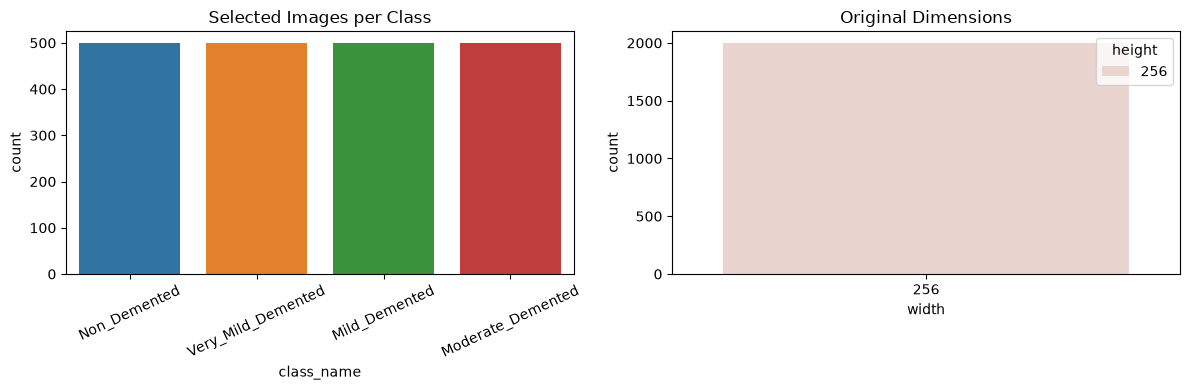

class_name
Mild_Demented         500
Moderate_Demented     500
Non_Demented          500
Very_Mild_Demented    500
Name: images, dtype: int64

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(
    data=manifest, x="class_name", hue="class_name", ax=axes[0], legend=False
)
axes[0].set_title("Selected Images per Class")
axes[0].tick_params(axis="x", rotation=25)

dimension_counts = manifest.value_counts(["width", "height"]).reset_index(name="count")
sns.barplot(data=dimension_counts, x="width", y="count", hue="height", ax=axes[1])
axes[1].set_title("Original Dimensions")
plt.tight_layout()
plt.show()

manifest.groupby("class_name").size().rename("images")

## Training, validation, and test split

We use 70% of the data for training, 15% for validation, and 15% for testing. Stratification approximately preserves class proportions in each subset. The test set remains untouched until final evaluation.

In [6]:
train_val, test_manifest = train_test_split(
    manifest, test_size=0.15, random_state=SEED, stratify=manifest["label"]
)
train_manifest, val_manifest = train_test_split(
    train_val, test_size=0.15 / 0.85, random_state=SEED,
    stratify=train_val["label"]
)

train_manifest = train_manifest.assign(split="train")
val_manifest = val_manifest.assign(split="validation")
test_manifest = test_manifest.assign(split="test")

manifest = pd.concat([train_manifest, val_manifest, test_manifest], ignore_index=True)
manifest = manifest.sample(frac=1, random_state=SEED).reset_index(drop=True)
manifest.to_csv(MANIFEST_PATH, index=False)

split_table = pd.crosstab(manifest["split"], manifest["class_name"])
print(f"Manifest saved to: {MANIFEST_PATH.resolve()}")
split_table

Manifest saved to: C:\Users\lenin\Projects\work\work-Other.NeuralNetworks\data\alzheimer_mri_manifest.csv


class_name,Mild_Demented,Moderate_Demented,Non_Demented,Very_Mild_Demented
split,,,,
test,75,75,75,75
train,350,350,350,350
validation,75,75,75,75


## Visualize training samples

Visual inspection helps identify corrupted files, unexpected orientations, artifacts, and contrast differences before training.

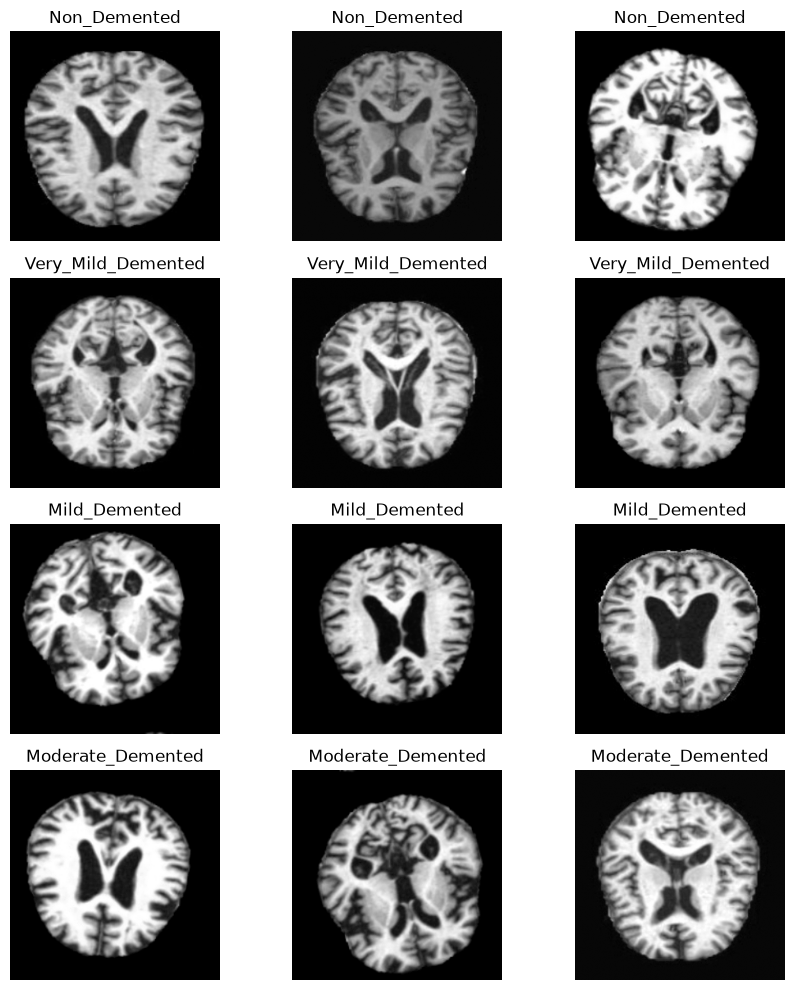

In [7]:
fig, axes = plt.subplots(len(CLASS_NAMES), 3, figsize=(9, 10))

for row, class_name in enumerate(CLASS_NAMES):
    examples = manifest.query("split == 'train' and class_name == @class_name").sample(
        n=3, random_state=SEED
    )
    for column, record in enumerate(examples.itertuples()):
        image = Image.open(DATA_DIR / record.relative_path).convert("L")
        axes[row, column].imshow(image, cmap="gray")
        axes[row, column].set_title(class_name)
        axes[row, column].axis("off")

plt.tight_layout()
plt.show()

## Data limitations

- The complete dataset is relatively balanced, with each class containing between 2,188 and 2,460 images. Because this lesson limits every class to `MAX_IMAGES_PER_CLASS`, the resulting manifest is balanced as long as that limit does not exceed the size of the smallest class.
- File names do not provide reliable patient identifiers. Therefore, samples are separated by **image**, not by patient. If multiple slices from the same patient exist, leakage between subsets may occur.
- The classes represent ordered disease stages, but this lesson treats them as four categorical classes.